# w207 Final Project

Healthy vs. Bleached Coral Images Dataset

Notebook authored by Mackenzie Henderson

# Import necessary libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow import keras
from keras import metrics

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

DATA_PATH = 'coral_images'

# Import Preprocessing notebook

In [2]:
before = set(globals().keys())

In [3]:
%%capture
%run -i coral_images_preprocessing.ipynb

2026-04-17 18:26:28.664789: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-17 18:26:28.664979: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-17 18:26:28.664988: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-04-17 18:26:28.665180: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-17 18:26:28.665190: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
after = set(globals().keys())
new_vars = after - before
#variables from exported notebook above

# Improvement Model

### Build & Fit Model

In [5]:
def build_cnn():
    model = Sequential()

    # convolutional layers
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    # flatten
    model.add(Flatten())

    # dense layers
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
def plot_cnn_history(model, epochs):
    # Creating loss and accuracy variables for plotting
    cnn_loss = model.history.history['loss']
    cnn_accuracy = model.history.history['accuracy']
    cnn_val_loss = model.history.history['val_loss']
    cnn_val_accuracy = model.history.history['val_accuracy']

    # Creating 1x2 plot
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # Plotting Training Data Loss Values
    ax[0].plot(range(1, epochs+1), cnn_loss, marker='o', label = "Training Loss")
    ax[0].plot(range(1, epochs+1), cnn_val_loss, marker='o', label = "Validation Loss")
    ax[0].set_title("Cross-Entropy Loss of TensorFlow CNN Model")
    ax[0].set_xlabel("Epoch Number")
    ax[0].set_ylabel("Cross-Entropy Loss Values")
    ax[0].legend()

    # Plotting Training Data Accuracy Values
    ax[1].plot(range(1, epochs+1), cnn_accuracy, marker='o', label = "Training Accuracy")
    ax[1].plot(range(1, epochs+1), cnn_val_accuracy, marker = 'o', label = "Validation Accuracy")
    ax[1].set_title("Accuracy of TensorFlow CNN Model")
    ax[1].set_xlabel("Epoch Number")
    ax[1].set_ylabel("Accuracy Values")
    ax[1].tick_params(labelleft=True)
    ax[1].legend()

    plt.show()

    print(f'Training accuracy: {cnn_accuracy[-1]:.2%}')
    print(f'Validation accuracy: {cnn_val_accuracy[-1]:.2%}')
    print(f'Training loss: {cnn_loss[-1]:.3f}')
    print(f'Validation loss: {cnn_val_loss[-1]:.3f}')

In [7]:
cnn = build_cnn()

history = cnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10


2026-04-17 18:26:39.991516: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 138ms/step - accuracy: 0.6266 - loss: 0.7411 - val_accuracy: 0.6649 - val_loss: 0.5626
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.7089 - loss: 0.5678 - val_accuracy: 0.7027 - val_loss: 0.5352
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.7080 - loss: 0.5668 - val_accuracy: 0.6973 - val_loss: 0.5901
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.7468 - loss: 0.5323 - val_accuracy: 0.7081 - val_loss: 0.5666
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.7631 - loss: 0.5050 - val_accuracy: 0.6811 - val_loss: 0.6415
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.7830 - loss: 0.4776 - val_accuracy: 0.6595 - val_loss: 0.7987
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.8083 - loss: 0.4351 - val_accuracy: 0.7081 - val_loss: 0.7635
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.8291 - loss: 0.4155 - val_accuracy: 0.6595 - val_

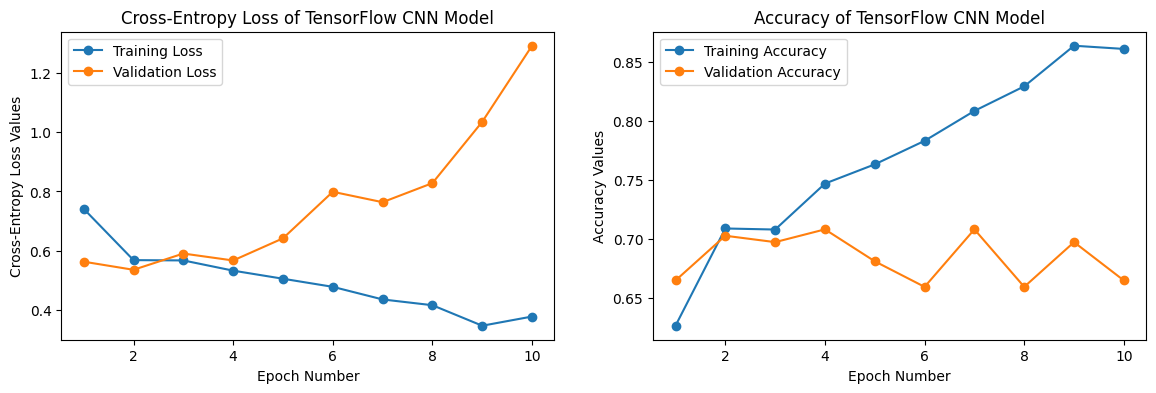

Training accuracy: 86.08%
Validation accuracy: 66.49%
Training loss: 0.377
Validation loss: 1.292


In [8]:
plot_cnn_history(cnn, epochs=10)

Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.5841 - loss: 1.0400 - val_accuracy: 0.6811 - val_loss: 0.6423
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.7025 - loss: 0.5845 - val_accuracy: 0.6649 - val_loss: 0.6649
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.7306 - loss: 0.5647 - val_accuracy: 0.7351 - val_loss: 0.5565
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.7315 - loss: 0.5785 - val_accuracy: 0.6865 - val_loss: 0.5555
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.7152 - loss: 0.8586 - val_accuracy: 0.6973 - val_loss: 0.7309


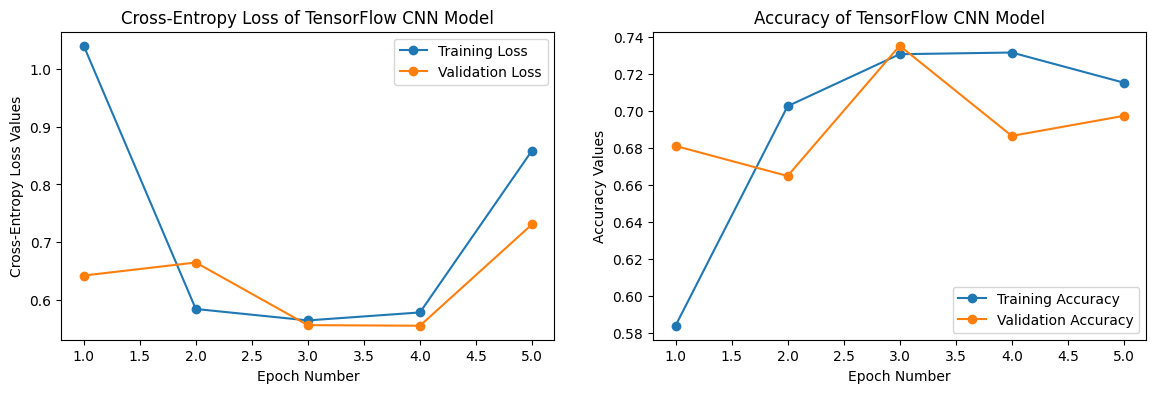

Training accuracy: 71.52%
Validation accuracy: 69.73%
Training loss: 0.859
Validation loss: 0.731


In [37]:
cnn = build_cnn()

history = cnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_val, y_val)
)

plot_cnn_history(cnn, epochs=5)

### Test Model

In [38]:
loss, acc = cnn.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7081 - loss: 0.6255
Test Accuracy: 0.7081


### Confusion Matrix

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


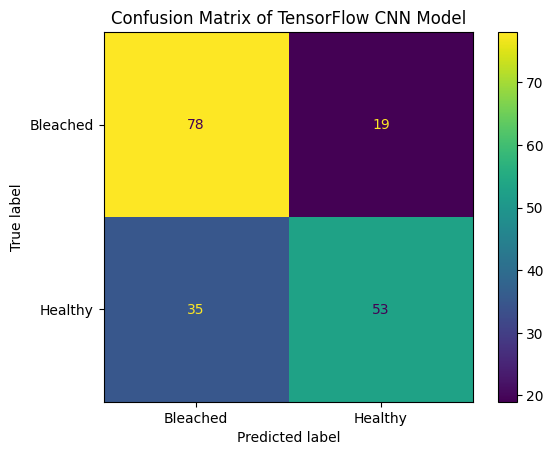

In [39]:
# Generating confusion matrix for CNN model predictions

y_pred = (cnn.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bleached", "Healthy"]
)
disp.plot()
plt.title("Confusion Matrix of TensorFlow CNN Model")
plt.show()

In [40]:

print("CNN Test Accuracy:", acc)

CNN Test Accuracy: 0.708108127117157


# Tuned CNN Model

### Build Model

In [30]:
### Build Tuned CNN Model
def build_tuned_cnn(dense_units, dropout_rate, learning_rate):

    model = Sequential()

    tf.keras.utils.set_random_seed(42)

    # convolutional layers
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    # flatten
    model.add(Flatten())

    # dense layers
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

### Run Hyperparameter Search

In [31]:
param_grid = [
    {'dense_units': 64,  'dropout_rate': 0.3, 'learning_rate': 0.001,  'batch_size': 32, 'epochs': 8},
    {'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.001,  'batch_size': 32, 'epochs': 10},
    {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 10},
    {'dense_units': 256, 'dropout_rate': 0.5, 'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 10}
]

results = []

best_val_accuracy = 0
best_model = None
best_history = None
best_params = None

for i, params in enumerate(param_grid):
    print(f"Training model {i+1} of {len(param_grid)}")
    print(params)

    tf.keras.backend.clear_session()

    model = build_tuned_cnn(
        dense_units=params['dense_units'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    history = model.fit(
        X_train, y_train,
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        validation_data=(X_val, y_val),
        verbose=1
    )

    current_val_accuracy = max(history.history['val_accuracy'])
    current_train_accuracy = max(history.history['accuracy'])

    results.append({
        'dense_units': params['dense_units'],
        'dropout_rate': params['dropout_rate'],
        'learning_rate': params['learning_rate'],
        'batch_size': params['batch_size'],
        'epochs': params['epochs'],
        'train_accuracy': current_train_accuracy,
        'val_accuracy': current_val_accuracy
    })

    if current_val_accuracy > best_val_accuracy:
        best_val_accuracy = current_val_accuracy
        best_model = model
        best_history = history
        best_params = params

Training model 1 of 4
{'dense_units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 8}
Epoch 1/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5054 - loss: 4.6168 - val_accuracy: 0.4811 - val_loss: 2.0790
Epoch 2/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.5769 - loss: 2.5790 - val_accuracy: 0.5676 - val_loss: 1.2864
Epoch 3/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.5823 - loss: 2.0388 - val_accuracy: 0.6216 - val_loss: 0.7289
Epoch 4/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.6618 - loss: 0.6339 - val_accuracy: 0.6973 - val_loss: 0.6324
Epoch 5/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6872 - loss: 0.6462 - val_accuracy: 0.6973 - val_loss: 0.6090
Epoch 6/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.7125 - loss: 0.6232 - val_accuracy: 0.7297 - val_loss: 0.5898
Epoch 7/8
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.7269 - loss: 0.6528 - val_accuracy: 0.7189 - val_loss: 0.5851

### Hyperparameter Tuning Results

In [32]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='val_accuracy', ascending=False).reset_index(drop=True)
results_df

,dense_units,dropout_rate,learning_rate,batch_size,epochs,train_accuracy,val_accuracy
0,128,0.3,0.0005,32,10,0.795660,0.756757
1,64,0.3,0.0010,32,8,0.740506,0.729730
2,128,0.5,0.0010,32,10,0.744123,0.729730
3,256,0.5,0.0005,32,10,0.760398,0.724324


### Plot Best Tuned Model History

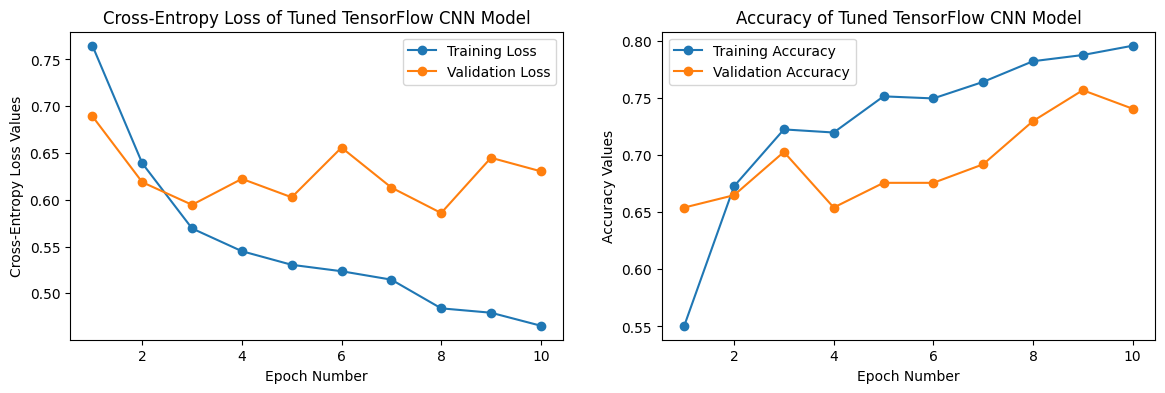

Best Parameters: {'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 10}
Final Training Accuracy: 79.57%
Final Validation Accuracy: 74.05%
Final Training Loss: 0.465
Final Validation Loss: 0.631


In [33]:
### Plotting Best Tuned CNN Results

tuned_loss = best_history.history['loss']
tuned_accuracy = best_history.history['accuracy']
tuned_val_loss = best_history.history['val_loss']
tuned_val_accuracy = best_history.history['val_accuracy']

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Plotting Training Data Loss Values
ax[0].plot(range(1, len(tuned_loss)+1), tuned_loss, marker='o', label="Training Loss")
ax[0].plot(range(1, len(tuned_val_loss)+1), tuned_val_loss, marker='o', label="Validation Loss")
ax[0].set_title("Cross-Entropy Loss of Tuned TensorFlow CNN Model")
ax[0].set_xlabel("Epoch Number")
ax[0].set_ylabel("Cross-Entropy Loss Values")
ax[0].legend()

# Plotting Training Data Accuracy Values
ax[1].plot(range(1, len(tuned_accuracy)+1), tuned_accuracy, marker='o', label="Training Accuracy")
ax[1].plot(range(1, len(tuned_val_accuracy)+1), tuned_val_accuracy, marker='o', label="Validation Accuracy")
ax[1].set_title("Accuracy of Tuned TensorFlow CNN Model")
ax[1].set_xlabel("Epoch Number")
ax[1].set_ylabel("Accuracy Values")
ax[1].tick_params(labelleft=True)
ax[1].legend()

plt.show()

print("Best Parameters:", best_params)
print(f"Final Training Accuracy: {tuned_accuracy[-1]:.2%}")
print(f"Final Validation Accuracy: {tuned_val_accuracy[-1]:.2%}")
print(f"Final Training Loss: {tuned_loss[-1]:.3f}")
print(f"Final Validation Loss: {tuned_val_loss[-1]:.3f}")

### Test Tuned Model

In [41]:
### Test Tuned Model

tuned_test_loss, tuned_test_acc = best_model.evaluate(X_test, y_test)

print(f"Tuned CNN Test Accuracy: {tuned_test_acc:.4f}")
print(f"Tuned CNN Test Loss: {tuned_test_loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7514 - loss: 0.6199
Tuned CNN Test Accuracy: 0.7514
Tuned CNN Test Loss: 0.6199


### Confusion Matrix for Tuned CNN

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


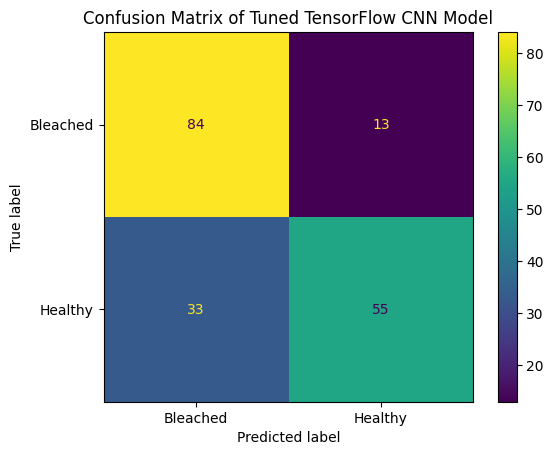

In [42]:
y_pred_tuned = (best_model.predict(X_test) > 0.5).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Bleached", "Healthy"]
)

disp.plot()
plt.title("Confusion Matrix of Tuned TensorFlow CNN Model")
plt.show()

### Model Comparison

In [43]:
print("Baseline Test Accuracy:", .65)
print("CNN Test Accuracy:", acc)
print("Tuned CNN Test Accuracy:", tuned_test_acc)

Baseline Test Accuracy: 0.65
CNN Test Accuracy: 0.708108127117157
Tuned CNN Test Accuracy: 0.7513513565063477
